# Thống kê số lượng nhãn chính (L1)

Notebook này đọc dữ liệu từ `raw_data.json` và vẽ biểu đồ phân bố số lượng theo `label_l1`.

In [1]:
import json
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [2]:
from pathlib import Path
PROJECT_DIR = Path.cwd().parent
DATA_FILE = str(PROJECT_DIR / 'data' / 'raw' / 'raw_data.json')

with open(DATA_FILE, 'r', encoding='utf-8') as f:
    data = json.load(f)

len(data)

7964

In [3]:
label_counts = Counter(item.get('label_l1', '').strip() for item in data)
if '' in label_counts:
    del label_counts['']

df = (
    pd.DataFrame(label_counts.items(), columns=['label_l1', 'count'])
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)
df['percent'] = (df['count'] / df['count'].sum() * 100).round(2)
df

,label_l1,count,percent
0,Thể thao,953,11.97
1,Thế giới,929,11.66
2,Xe,903,11.34
3,Khoa học,862,10.82
4,Thời sự,590,7.41
5,Sức khỏe,540,6.78
6,Kinh doanh,469,5.89
7,Đời sống,465,5.84
8,Giáo dục,464,5.83
9,Giải trí,460,5.78


C:\Users\Admin\AppData\Local\Temp\ipykernel_14264\3326662964.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='label_l1', y='count', palette='Blues_r')


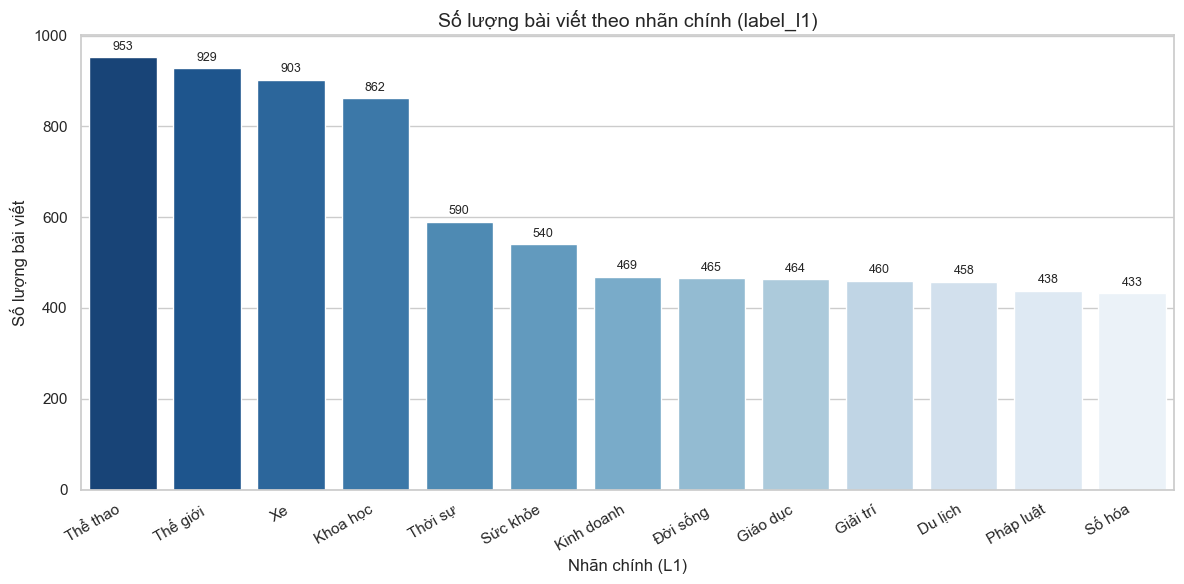

In [4]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df, x='label_l1', y='count', palette='Blues_r')

for i, v in enumerate(df['count']):
    ax.text(i, v + max(df['count']) * 0.01, str(v), ha='center', va='bottom', fontsize=9)

plt.title('Số lượng bài viết theo nhãn chính (label_l1)', fontsize=14)
plt.xlabel('Nhãn chính (L1)')
plt.ylabel('Số lượng bài viết')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

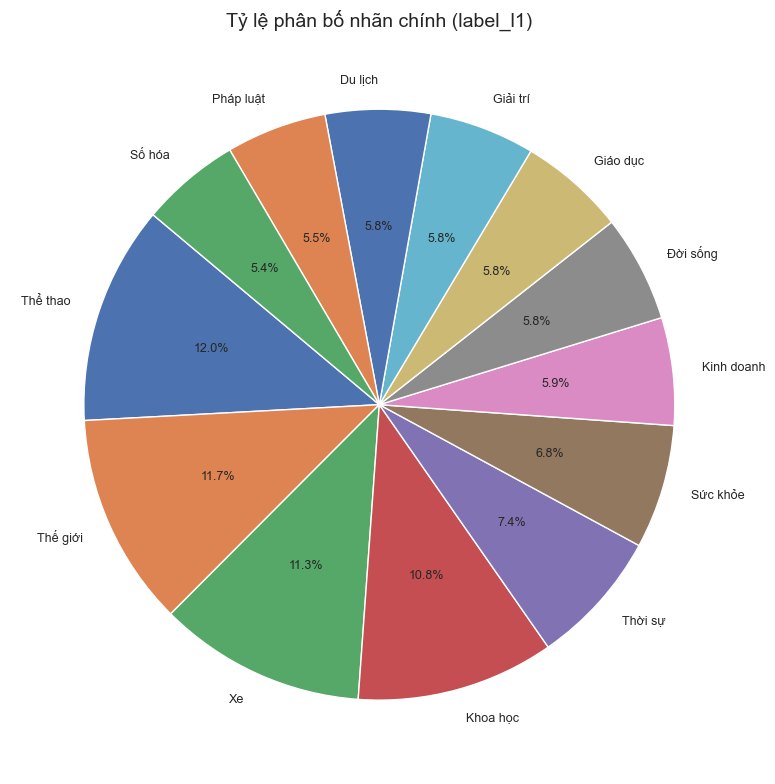

In [5]:
plt.figure(figsize=(8, 8))
plt.pie(
    df['count'],
    labels=df['label_l1'],
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 9}
)
plt.title('Tỷ lệ phân bố nhãn chính (label_l1)', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# Nếu cần lưu bảng thống kê ra CSV
# df.to_csv('label_l1_stats.csv', index=False, encoding='utf-8-sig')
df.head(20)

,label_l1,count,percent
0,Thể thao,953,15.27
1,Thời sự,590,9.45
2,Sức khỏe,540,8.65
3,Kinh doanh,469,7.51
4,Đời sống,465,7.45
5,Giáo dục,464,7.43
6,Giải trí,460,7.37
7,Du lịch,458,7.34
8,Pháp luật,438,7.02
9,Số hóa,433,6.94


## Thống kê nhãn cấp 2 (L2) và cấp 3 (L3)

Các biểu đồ dưới đây hiển thị **toàn bộ nhãn không rỗng** của `label_l2` và `label_l3`.

In [6]:
def build_label_stats(data, field_name):
    counts = Counter(item.get(field_name, '').strip() for item in data)
    if '' in counts:
        del counts['']

    df_stats = (
        pd.DataFrame(counts.items(), columns=[field_name, 'count'])
        .sort_values('count', ascending=False)
        .reset_index(drop=True)
    )
    df_stats['percent'] = (df_stats['count'] / df_stats['count'].sum() * 100).round(2)
    return df_stats


def plot_all_labels(df_stats, label_col, title):
    fig_height = max(6, len(df_stats) * 0.35)
    plt.figure(figsize=(14, fig_height))
    ax = sns.barplot(data=df_stats, y=label_col, x='count', palette='viridis')

    for i, value in enumerate(df_stats['count']):
        ax.text(value + max(df_stats['count']) * 0.005, i, str(value), va='center', fontsize=9)

    plt.title(title, fontsize=14)
    plt.xlabel('Số lượng bài viết')
    plt.ylabel('Nhãn')
    plt.tight_layout()
    plt.show()

Số nhãn label_l2 (không rỗng): 90


,label_l2,count,percent
0,Tin tức,495,8.05
1,Thị trường,438,7.13
2,Các bệnh,347,5.65
3,Tennis,305,4.96
4,Bóng đá,295,4.80
...,...,...,...
85,GameVerse 2025,1,0.02
86,Chính sách,1,0.02
87,Sea Games 33,1,0.02
88,Sáng kiến khoa học 2025,1,0.02


C:\Users\Admin\AppData\Local\Temp\ipykernel_14264\1556584629.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_stats, y=label_col, x='count', palette='viridis')


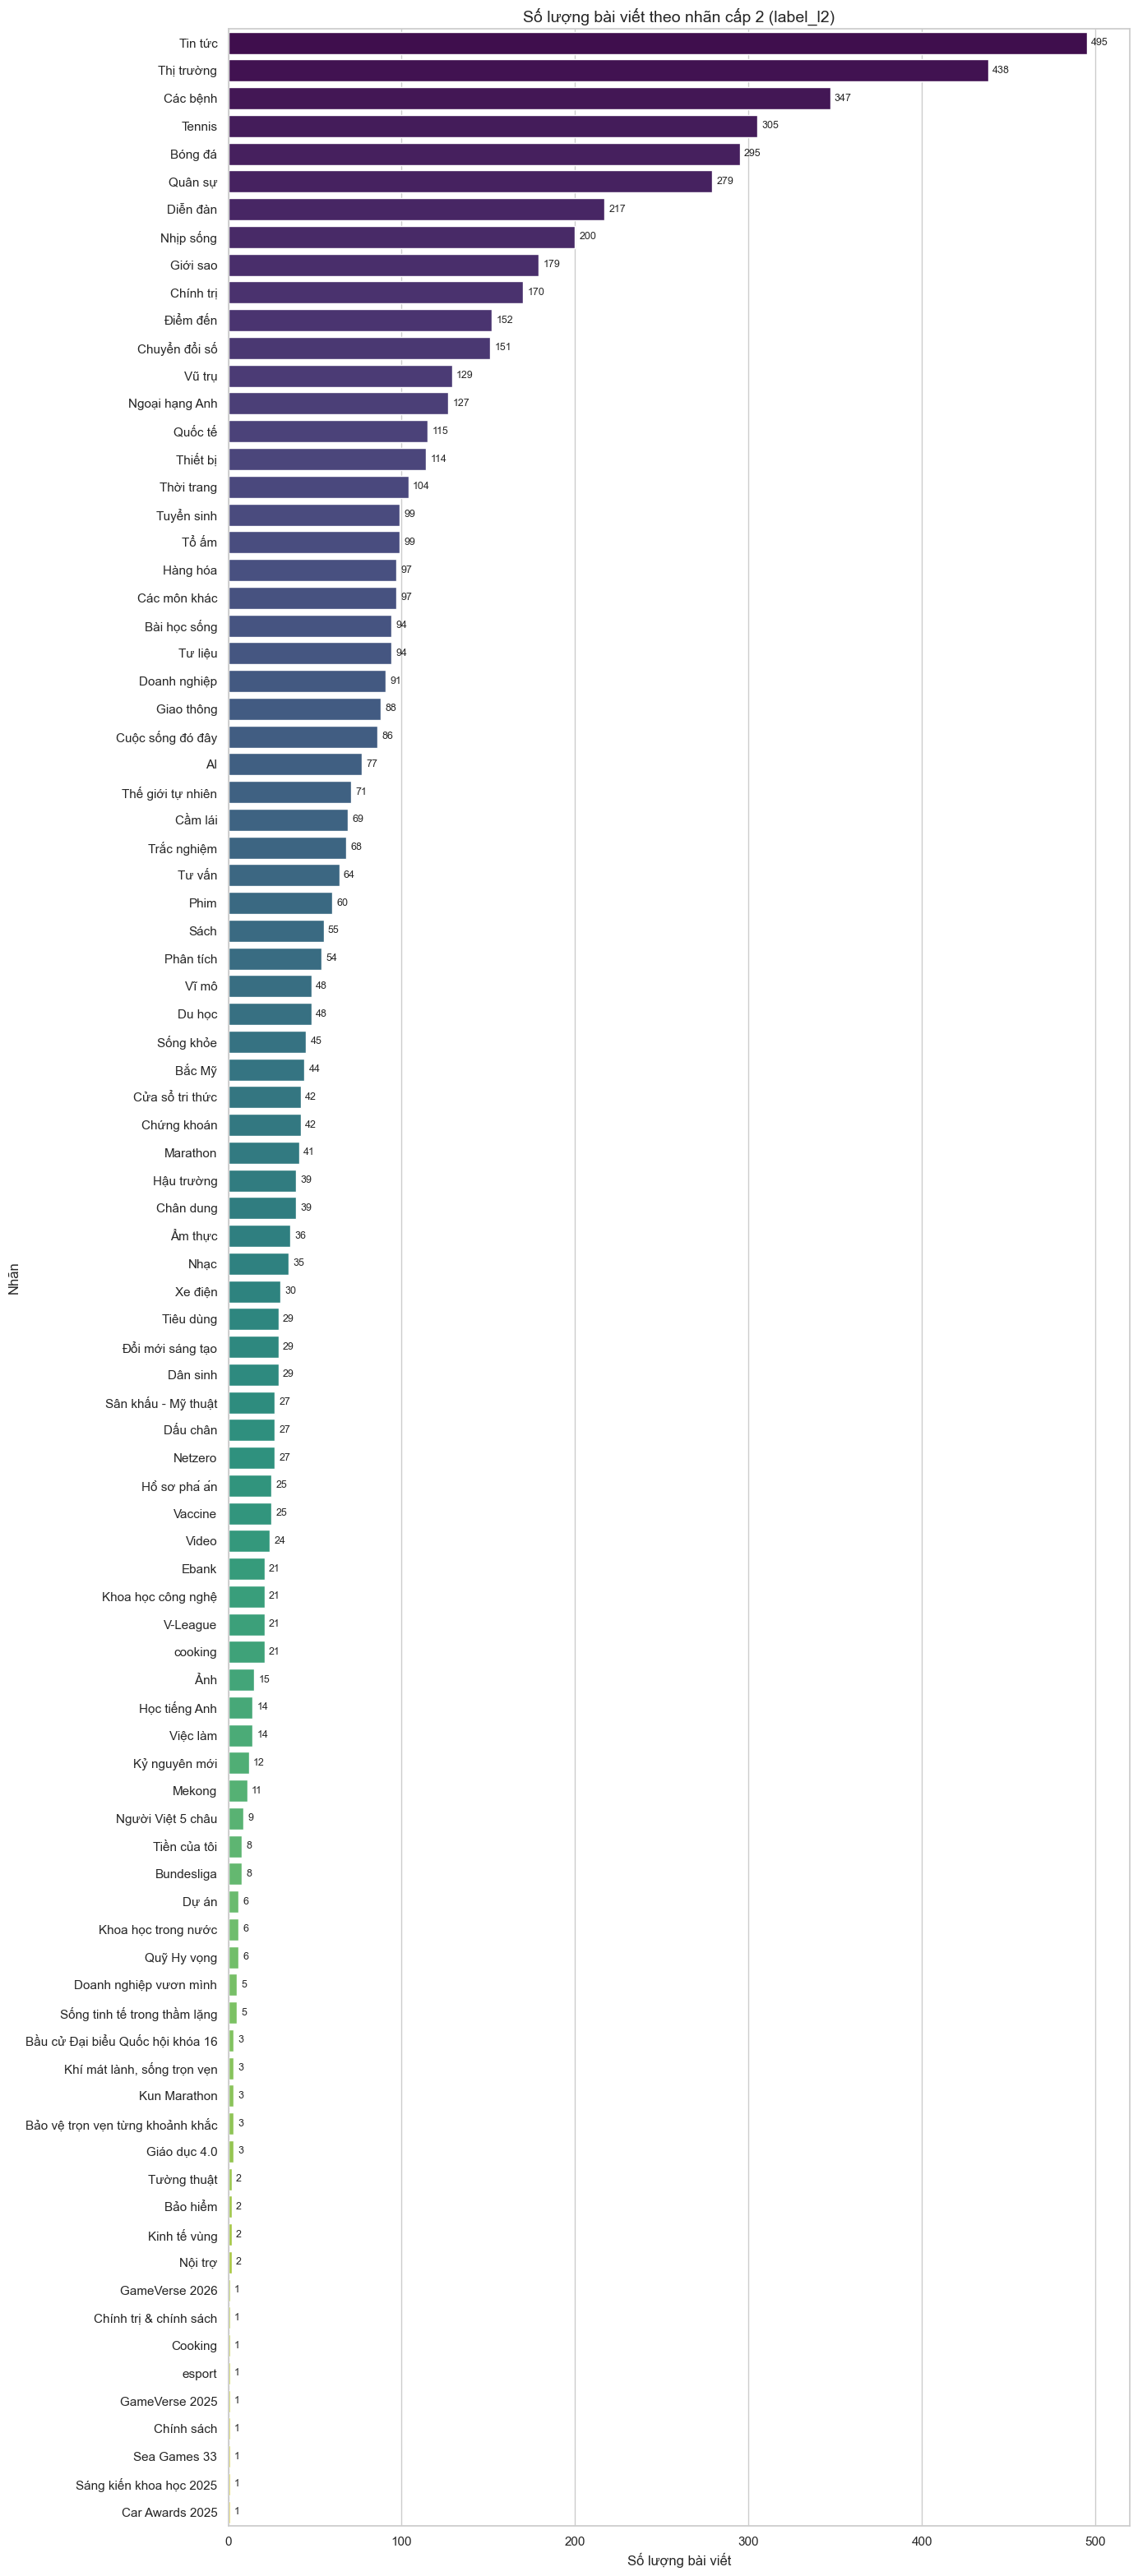

In [7]:
# Thống kê và vẽ biểu đồ cho label_l2

df_l2 = build_label_stats(data, 'label_l2')
print(f"Số nhãn label_l2 (không rỗng): {len(df_l2)}")
display(df_l2)

plot_all_labels(
    df_l2,
    label_col='label_l2',
    title='Số lượng bài viết theo nhãn cấp 2 (label_l2)'
)

Số nhãn label_l3 (không rỗng): 102


,label_l3,count,percent
0,Trong nước,246,10.14
1,Thế giới,242,9.98
2,Các giải khác,167,6.89
3,Tin tức,160,6.60
4,Tình huống,125,5.15
...,...,...,...
97,Hành tinh kêu cứu,1,0.04
98,Tin dự án,1,0.04
99,Đổi mới sáng tạo,1,0.04
100,Cẩm nang Net Zero,1,0.04


C:\Users\Admin\AppData\Local\Temp\ipykernel_14264\1556584629.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_stats, y=label_col, x='count', palette='viridis')


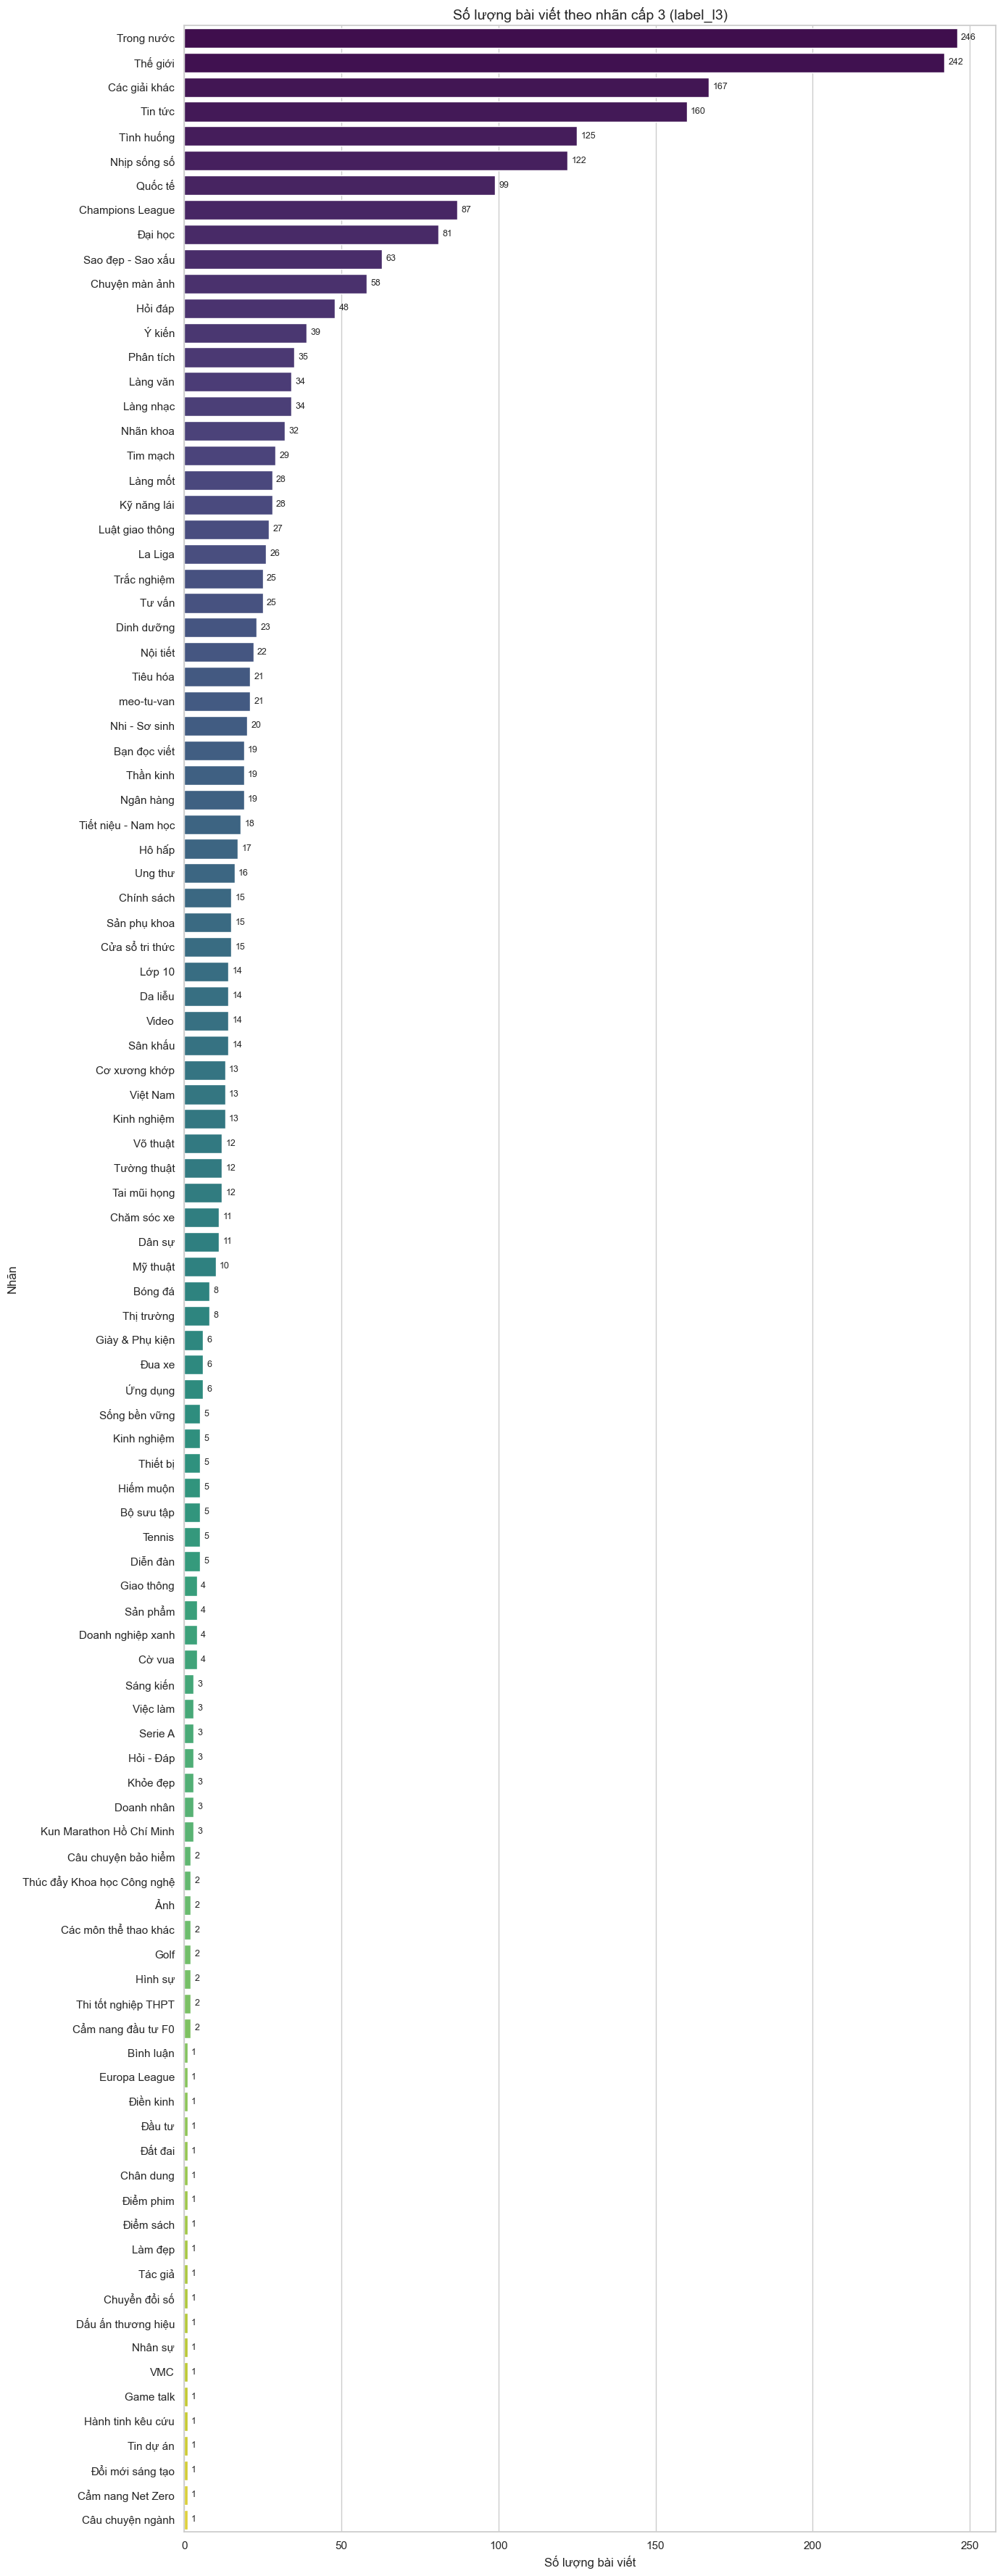

In [8]:
# Thống kê và vẽ biểu đồ cho label_l3

df_l3 = build_label_stats(data, 'label_l3')
print(f"Số nhãn label_l3 (không rỗng): {len(df_l3)}")
display(df_l3)

plot_all_labels(
    df_l3,
    label_col='label_l3',
    title='Số lượng bài viết theo nhãn cấp 3 (label_l3)'
)

## Thống kê nhãn sau tiền xử lý (dataset.json)

Đọc từ `dataset.json` — dữ liệu đã qua normalize, merge, drop nhãn.
So sánh với raw để thấy bao nhiêu bài/nhãn bị lọc.


Tổng bài sau tiền xử lý: 7,954
Tổng bài raw            : 7,964
Bị lọc bỏ              : 10 (0.1%)

Số nhãn L1 unique: 13
Số nhãn L2 unique: 38  (bài có L2: 5,121 = 64.4%)
Số nhãn L3 unique: 19  (bài có L3: 1,351 = 17.0%)

  PHÂN PHỐI L1 (sau tiền xử lý)


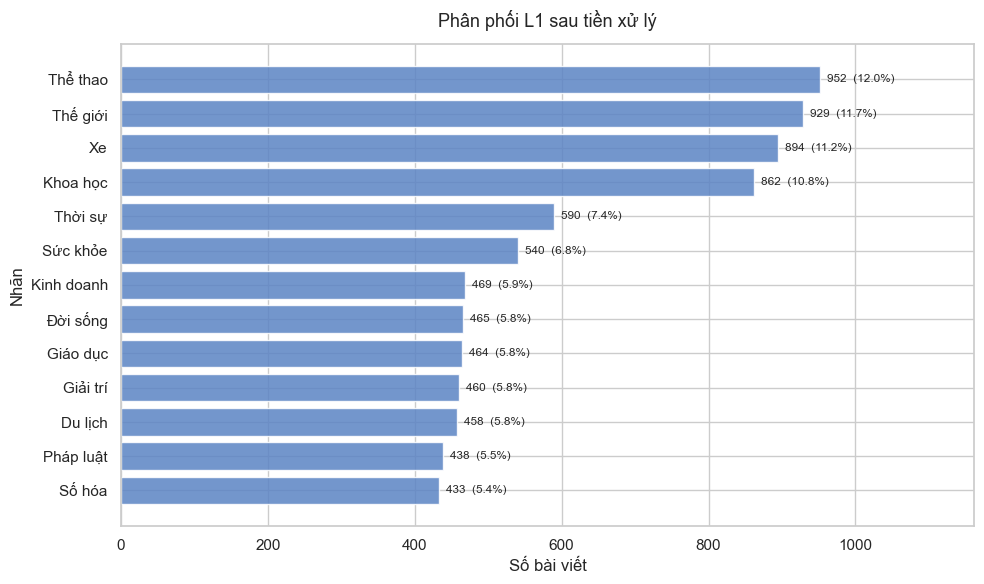

,label,số bài,%
0,Thể thao,952,11.968821
1,Thế giới,929,11.679658
2,Xe,894,11.239628
3,Khoa học,862,10.837315
4,Thời sự,590,7.417651
5,Sức khỏe,540,6.789037
6,Kinh doanh,469,5.896404
7,Đời sống,465,5.846115
8,Giáo dục,464,5.833543
9,Giải trí,460,5.783254



  PHÂN PHỐI L2 (sau tiền xử lý)


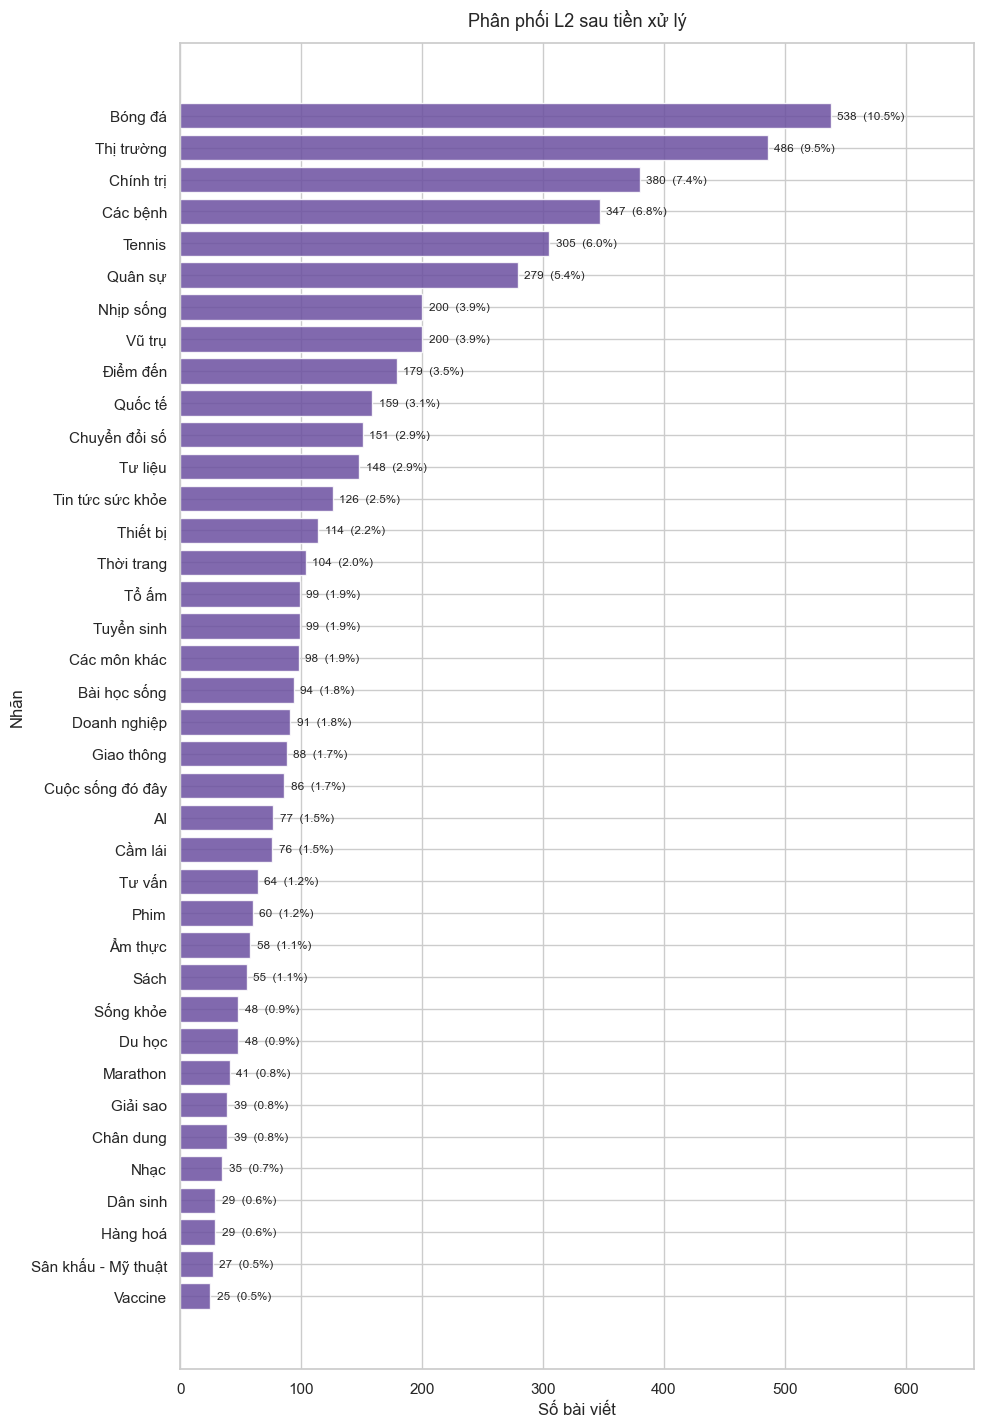

,label,số bài,%
0,Bóng đá,538,10.505761
1,Thị trường,486,9.490334
2,Chính trị,380,7.420426
3,Các bệnh,347,6.776020
4,Tennis,305,5.955868
5,Quân sự,279,5.448155
6,Nhịp sống,200,3.905487
7,Vũ trụ,200,3.905487
8,Điểm đến,179,3.495411
9,Quốc tế,159,3.104862



  PHÂN PHỐI L3 (sau tiền xử lý)


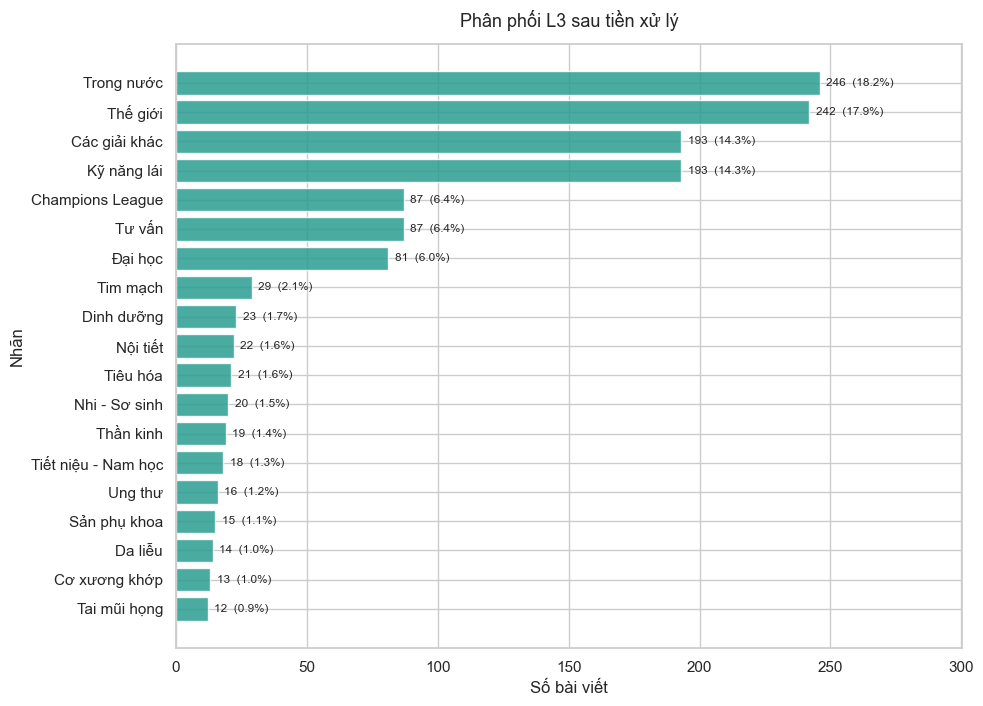

,label,số bài,%
0,Trong nước,246,18.208734
1,Thế giới,242,17.912657
2,Các giải khác,193,14.285714
3,Kỹ năng lái,193,14.285714
4,Champions League,87,6.439674
5,Tư vấn,87,6.439674
6,Đại học,81,5.995559
7,Tim mạch,29,2.146558
8,Dinh dưỡng,23,1.702443
9,Nội tiết,22,1.628423



  SO SÁNH RAW vs SAU TIỀN XỬ LÝ
                              Raw    Processed     Giảm
  -------------------------------------------------------
  Tổng bài                  7,964        7,954       10
  Nhãn L1 unique               13           13        0
  Nhãn L2 unique               90           38       52
  Nhãn L3 unique              102           19       83


In [9]:
import json, pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATASET_FILE = str(PROJECT_DIR / 'data' / 'process_data' / 'dataset.json')

with open(DATASET_FILE, encoding='utf-8') as f:
    dataset = json.load(f)

print(f'Tổng bài sau tiền xử lý: {len(dataset):,}')
print(f'Tổng bài raw            : {len(data):,}')
print(f'Bị lọc bỏ              : {len(data)-len(dataset):,} ({(len(data)-len(dataset))/len(data)*100:.1f}%)')
print()

# ── Đếm nhãn ─────────────────────────────────────────────────────────────
c_l1 = Counter(a['labels_l1'][0] for a in dataset if a['labels_l1'])
c_l2 = Counter(a['labels_l2'][0] for a in dataset if a['labels_l2'])
c_l3 = Counter(a['labels_l3'][0] for a in dataset if a['labels_l3'])

has_l2 = sum(1 for a in dataset if a['labels_l2'])
has_l3 = sum(1 for a in dataset if a['labels_l3'])

print(f'Số nhãn L1 unique: {len(c_l1)}')
print(f'Số nhãn L2 unique: {len(c_l2)}  (bài có L2: {has_l2:,} = {has_l2/len(dataset)*100:.1f}%)')
print(f'Số nhãn L3 unique: {len(c_l3)}  (bài có L3: {has_l3:,} = {has_l3/len(dataset)*100:.1f}%)')

# ── Hàm vẽ bar chart ──────────────────────────────────────────────────────
def plot_label_dist(counter, title, figsize, fig_color='#5B84C4'):
    df = (pd.DataFrame(counter.items(), columns=['label', 'count'])
            .sort_values('count', ascending=False)
            .reset_index(drop=True))
    df['percent'] = df['count'] / df['count'].sum() * 100

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(df['label'][::-1], df['count'][::-1], color=fig_color, alpha=0.85)

    max_count = df['count'].max()
    for bar, (_, row) in zip(bars, df[::-1].iterrows()):
        ax.text(bar.get_width() + max_count * 0.01, bar.get_y() + bar.get_height()/2,
                f"{int(row['count'])}  ({row['percent']:.1f}%)",
                va='center', fontsize=8.5)

    ax.set_xlim(0, max_count * 1.22)
    ax.set_xlabel('Số bài viết')
    ax.set_ylabel('Nhãn')
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    plt.show()
    return df

# ── L1 ────────────────────────────────────────────────────────────────────
print('\n' + '='*55)
print('  PHÂN PHỐI L1 (sau tiền xử lý)')
print('='*55)
df_l1_post = plot_label_dist(c_l1, 'Phân phối L1 sau tiền xử lý', figsize=(10, 6))
display(df_l1_post.rename(columns={'count':'số bài','percent':'%'}))

# ── L2 ────────────────────────────────────────────────────────────────────
print('\n' + '='*55)
print('  PHÂN PHỐI L2 (sau tiền xử lý)')
print('='*55)
df_l2_post = plot_label_dist(
    c_l2, 'Phân phối L2 sau tiền xử lý',
    figsize=(10, max(6, len(c_l2) * 0.38)), fig_color='#6B4FA0'
)
display(df_l2_post.rename(columns={'count':'số bài','percent':'%'}))

# ── L3 ────────────────────────────────────────────────────────────────────
print('\n' + '='*55)
print('  PHÂN PHỐI L3 (sau tiền xử lý)')
print('='*55)
df_l3_post = plot_label_dist(
    c_l3, 'Phân phối L3 sau tiền xử lý',
    figsize=(10, max(6, len(c_l3) * 0.38)), fig_color='#2A9D8F'
)
display(df_l3_post.rename(columns={'count':'số bài','percent':'%'}))

# ── So sánh raw vs processed ──────────────────────────────────────────────
print('\n' + '='*55)
print('  SO SÁNH RAW vs SAU TIỀN XỬ LÝ')
print('='*55)
raw_l1 = Counter(item.get('label_l1','').strip() for item in data if item.get('label_l1','').strip())
raw_l2 = Counter(item.get('label_l2','').strip() for item in data if item.get('label_l2','').strip())
raw_l3 = Counter(item.get('label_l3','').strip() for item in data if item.get('label_l3','').strip())

print(f'  {"":20} {"Raw":>10} {"Processed":>12} {"Giảm":>8}')
print(f'  {"-"*55}')
print(f'  {"Tổng bài":<20} {len(data):>10,} {len(dataset):>12,} {len(data)-len(dataset):>8,}')
print(f'  {"Nhãn L1 unique":<20} {len(raw_l1):>10} {len(c_l1):>12} {len(raw_l1)-len(c_l1):>8}')
print(f'  {"Nhãn L2 unique":<20} {len(raw_l2):>10} {len(c_l2):>12} {len(raw_l2)-len(c_l2):>8}')
print(f'  {"Nhãn L3 unique":<20} {len(raw_l3):>10} {len(c_l3):>12} {len(raw_l3)-len(c_l3):>8}')
